[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/colab-version/L05/L05_FONC_demonstration.ipynb)

# Demonstrating the First-Order Necessary Condition (FONC)
### MECH 559 - Systems Optimization - L05
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

A focused, hands-on companion to the FONC material in this lecture: build one reusable "find every stationary point" routine, then throw it at a genuinely multimodal function and a real least-squares fit, and see exactly what the FONC does and does not tell you.

## Learning objectives

By the end, students should be able to:

1. State the univariate and multivariate FONC and explain why it only produces *candidates*, not answers.
2. Implement a general-purpose stationary-point finder using a numerical gradient and multi-start root-finding.
3. Find every stationary point of a multimodal function and confirm each one satisfies $\nabla f=0$ to numerical precision.
4. Recognize a genuine engineering unconstrained problem - least-squares curve fitting - as an application of the FONC (the normal equations).

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49"}

print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. Recap: the first-order necessary condition

**Univariate.** If $x^\ast$ is a local minimizer of a differentiable $f$, then
$$
f'(x^\ast) = 0.
$$

**Multivariate.** If $\mathbf{x}^\ast$ is a local minimizer of a differentiable $f:\mathbb{R}^n\to\mathbb{R}$, then every partial derivative vanishes:
$$
\nabla f(\mathbf{x}^\ast) = \mathbf{0}.
$$

Both are *necessary*, not *sufficient*: a stationary point can be a minimizer, a maximizer, or a saddle. The FONC's job is only to narrow an infinite search space down to a finite (usually small) list of candidates - classifying them is the job of the companion SOSC notebook.

---
## 2. A reusable stationary-point finder

Given any differentiable $f$, we can estimate $\nabla f$ by central differences and hand it to a nonlinear-equation solver. Running this from many different starting guesses and de-duplicating the results is a simple, general way to find *all* the stationary points of a function we don't know much about in advance.

In [3]:
def numerical_gradient(func, x, h=1e-6):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    g = np.zeros_like(x)
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = h
        g[i] = (func(x + step) - func(x - step)) / (2 * h)
    return g

def find_stationary_points(func, starting_points, grad_tol=1e-6, dedupe_tol=1e-3):
    found = []
    for x0 in starting_points:
        x0 = np.atleast_1d(np.asarray(x0, dtype=float))
        x_star, info, ier, msg = fsolve(lambda x: numerical_gradient(func, x), x0, full_output=True)
        if ier != 1 or np.max(np.abs(numerical_gradient(func, x_star))) > grad_tol:
            continue
        if not any(np.linalg.norm(x_star - existing) < dedupe_tol for existing in found):
            found.append(x_star)
    return found

print("find_stationary_points ready.")

find_stationary_points ready.


---
## 3. Univariate example: a function with three stationary points

$$
f(x) = x^4 - 4x^2 + x
$$

> **Predict:** a quartic with a positive leading coefficient looks like a "W" - how many stationary points (flat tangents) do you expect, and roughly where?

x* = -1.472998   f(x*) = -5.444192   f'(x*) approx 8.88e-10
x* =  0.126000   f(x*) =  0.062748   f'(x*) approx 6.94e-12
x* =  1.346997   f(x*) = -2.618556   f'(x*) approx 2.22e-10


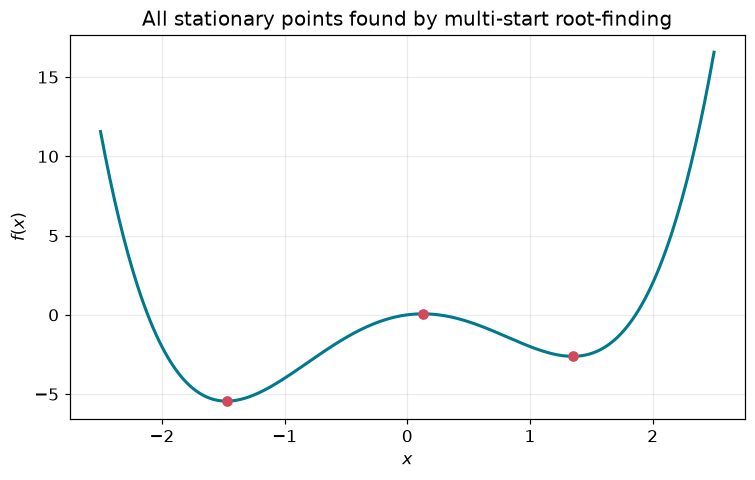


3 stationary points found. The FONC alone doesn't tell us which are minima or maxima.


In [4]:
def f_uni(x):
    (x1,) = x
    return x1**4 - 4*x1**2 + x1

def f_uni_vec(x):
    return x**4 - 4*x**2 + x

starts_uni = [[s] for s in np.linspace(-3, 3, 13)]
stationary_uni = sorted(find_stationary_points(f_uni, starts_uni), key=lambda p: p[0])

xx = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xx, f_uni_vec(xx), color=COLORS["boundary"], lw=2)
for x_star in stationary_uni:
    f_val = f_uni(x_star)
    ax.scatter([x_star[0]], [f_val], color=COLORS["optimum"], zorder=3)
    print(f"x* = {x_star[0]: .6f}   f(x*) = {f_val: .6f}   f'(x*) approx {numerical_gradient(f_uni, x_star)[0]:.2e}")
ax.set(xlabel="$x$", ylabel="$f(x)$", title="All stationary points found by multi-start root-finding")
plt.tight_layout()
plt.show()
print(f"\n{len(stationary_uni)} stationary points found. The FONC alone doesn't tell us which are minima or maxima.")

---
## 4. Multivariate example: Himmelblau's function

$$
f(x_1,x_2) = (x_1^2+x_2-11)^2 + (x_1+x_2^2-7)^2
$$

This is a classic multimodal test function - a good stress test for a stationary-point finder, because it is known to have **nine** stationary points (four minima, one maximum, and four saddles), but nothing about the formula tells you that up front.

> **Predict:** if we searched from only a single starting guess, how many of the nine stationary points would you expect to find?

9 distinct stationary points found from 49 starting guesses:

  x* = [-3.7793 -3.2832]   f(x*) =    0.0000   max|grad| = 3.31e-10
  x* = [-3.073  -0.0814]   f(x*) =  104.0152   max|grad| = 7.11e-09
  x* = [-2.8051  3.1313]   f(x*) =    0.0000   max|grad| = 2.76e-13
  x* = [-0.128  -1.9537]   f(x*) =  178.3372   max|grad| = 0.00e+00
  x* = [-0.2708 -0.923 ]   f(x*) =  181.6165   max|grad| = 1.42e-08
  x* = [0.0867 2.8843]   f(x*) =   67.7192   max|grad| = 7.11e-09
  x* = [3.3852 0.0739]   f(x*) =   13.3119   max|grad| = 1.78e-09
  x* = [ 3.5844 -1.8481]   f(x*) =    0.0000   max|grad| = 9.77e-12
  x* = [3. 2.]   f(x*) =    0.0000   max|grad| = 2.76e-12


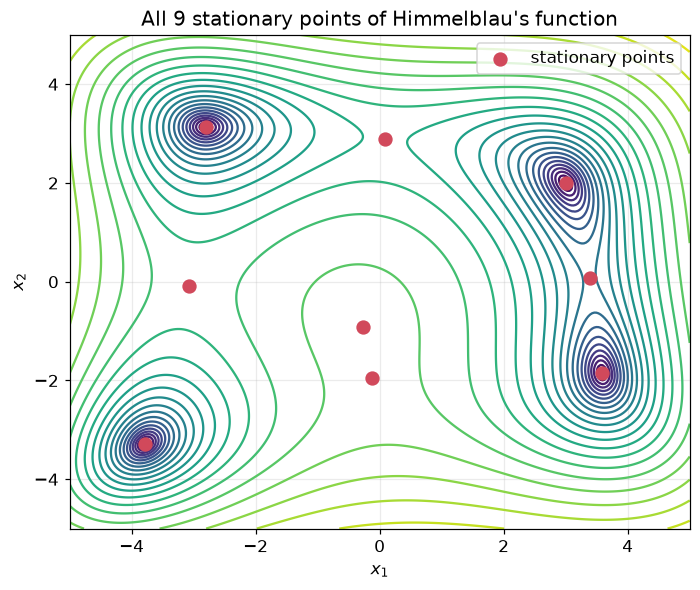


Every point above satisfies the FONC. Which are minima? See the SOSC notebook.


In [5]:
def himmelblau(x):
    x1, x2 = x
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

grid_1d = np.linspace(-5, 5, 7)
starts_2d = [[a, b] for a in grid_1d for b in grid_1d]
stationary_2d = find_stationary_points(himmelblau, starts_2d)

print(f"{len(stationary_2d)} distinct stationary points found from {len(starts_2d)} starting guesses:\n")
for x_star in stationary_2d:
    grad_norm = np.max(np.abs(numerical_gradient(himmelblau, x_star)))
    print(f"  x* = {np.round(x_star, 4)}   f(x*) = {himmelblau(x_star):9.4f}   max|grad| = {grad_norm:.2e}")

x1g, x2g = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
Z = (x1g**2 + x2g - 11)**2 + (x1g + x2g**2 - 7)**2
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.contour(x1g, x2g, np.log1p(Z), levels=25, cmap="viridis")
pts = np.array(stationary_2d)
ax.scatter(pts[:, 0], pts[:, 1], color=COLORS["optimum"], s=70, zorder=3, label="stationary points")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="All 9 stationary points of Himmelblau's function")
ax.legend()
plt.tight_layout()
plt.show()
print("\nEvery point above satisfies the FONC. Which are minima? See the SOSC notebook.")

---
## 5. Where the FONC actually shows up in engineering: least-squares fitting

Fitting a line $y = a x + b$ to noisy data by minimizing the sum of squared errors,

$$
\text{SSE}(a,b) = \sum_i (y_i - (ax_i+b))^2,
$$

is exactly the kind of unconstrained problem mentioned in the introduction to this lecture. Applying the FONC, $\nabla \text{SSE}=\mathbf{0}$, gives the classical **normal equations**. We solve them with our generic `find_stationary_points` and cross-check against `numpy.linalg.lstsq`.

FONC (via find_stationary_points): a=2.4209, b=-0.8794
np.linalg.lstsq:                   a=2.4209, b=-0.8794
gradient of SSE at the solution:    [-1.77635684e-09 -1.77635684e-09]


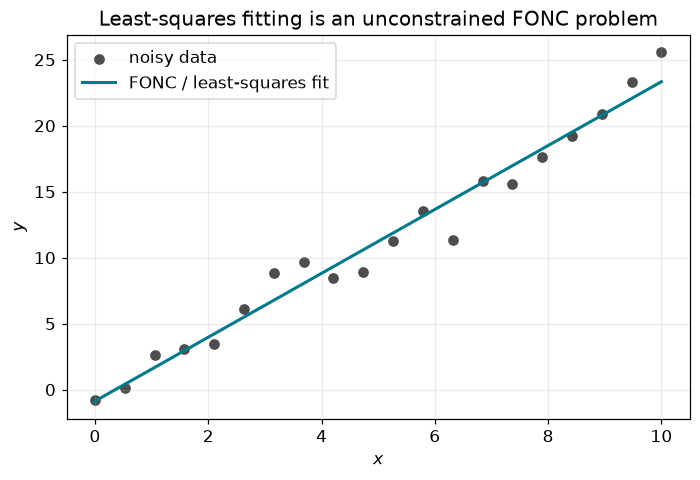

In [6]:
rng = np.random.default_rng(0)
n_pts = 20
x_data = np.linspace(0, 10, n_pts)
true_a, true_b = 2.5, -1.0
y_data = true_a * x_data + true_b + rng.normal(scale=1.5, size=n_pts)

def sse(params):
    a, b = params
    resid = y_data - (a * x_data + b)
    return np.sum(resid**2)

fonc_solution = find_stationary_points(sse, [[0.0, 0.0]])[0]
A_design = np.vstack([x_data, np.ones_like(x_data)]).T
lstsq_solution, *_ = np.linalg.lstsq(A_design, y_data, rcond=None)

print(f"FONC (via find_stationary_points): a={fonc_solution[0]:.4f}, b={fonc_solution[1]:.4f}")
print(f"np.linalg.lstsq:                   a={lstsq_solution[0]:.4f}, b={lstsq_solution[1]:.4f}")
print(f"gradient of SSE at the solution:    {numerical_gradient(sse, fonc_solution)}")
assert np.allclose(fonc_solution, lstsq_solution, atol=1e-3)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(x_data, y_data, color="0.3", label="noisy data")
xx = np.linspace(0, 10, 50)
ax.plot(xx, fonc_solution[0]*xx + fonc_solution[1], color=COLORS["boundary"], lw=2, label="FONC / least-squares fit")
ax.set(xlabel="$x$", ylabel="$y$", title="Least-squares fitting is an unconstrained FONC problem")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Interactive: watch the solver converge from different starting points

Pick a starting guess on Himmelblau's function and see which of the nine stationary points the search converges to.

In [7]:
def convergence_demo(x0=0.0, y0=0.0):
    x_star, info, ier, msg = fsolve(lambda x: numerical_gradient(himmelblau, x), [x0, y0], full_output=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contour(x1g, x2g, np.log1p(Z), levels=25, cmap="viridis")
    ax.scatter(pts[:, 0], pts[:, 1], color="0.6", s=40, label="all stationary points")
    ax.scatter([x0], [y0], color=COLORS["accent"], marker="s", s=70, label="start")
    ax.scatter([x_star[0]], [x_star[1]], color=COLORS["optimum"], s=90, label="converged to")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f"started at ({x0},{y0}) -> converged to {np.round(x_star, 4)}, f={himmelblau(x_star):.4f}")

if WIDGETS_AVAILABLE:
    display(widgets.interactive(convergence_demo,
                                 x0=widgets.FloatSlider(value=0.0, min=-5, max=5, step=0.25),
                                 y0=widgets.FloatSlider(value=0.0, min=-5, max=5, step=0.25)))
else:
    print("ipywidgets is not installed; running the default case.")
    convergence_demo()

interactive(children=(FloatSlider(value=0.0, description='x0', max=5.0, min=-5.0, step=0.25), FloatSlider(valu…

---
## Takeaways

1. The FONC turns "find the minimizer of $f$" into "solve $\nabla f(\mathbf{x})=\mathbf{0}$" - a root-finding problem, solvable the same way regardless of dimension.
2. A single starting guess only finds one stationary point; multi-start search is needed to find them all when $f$ is multimodal.
3. Every stationary point found this way satisfies $\nabla f=\mathbf{0}$ - but the FONC gives no information about which are minima, maxima, or saddles.
4. Least-squares fitting is a textbook example of an unconstrained optimization problem whose FONC (the normal equations) has a closed-form solution.

## Optional exercises

1. Reduce the starting-point grid to a single point, e.g. `[[0.0, 0.0]]`. How many of the nine stationary points does `find_stationary_points` find? Why?
2. Add a severe outlier to the least-squares data and re-solve. How much do $a,b$ move?
3. Apply `find_stationary_points` to $f(x_1,x_2)=\sin(x_1)\cos(x_2)$ over a wide grid of starting points in $[-2\pi,2\pi]^2$. How many stationary points do you find, and does that match what you'd expect from the periodicity of $\sin$ and $\cos$?